1. Project Introduction
2. Import Libraries
3. Define Data Parameters
4. Download Gold Price Data
5. Initial Inspection
6. Save Raw Data


# Gold Volatility Analysis

## Objective

This project analyzes the historical price behavior and volatility of gold.

The main objectives are:

- Analyze historical gold prices
- Calculate daily and log returns
- Measure historical and rolling volatility
- Investigate volatility clustering
- Model volatility using GARCH
- Evaluate market risk using VaR and Expected Shortfall

The analysis is designed as a financial analytics and quantitative research project.

## Phase 1 — Data Collection

In this phase, historical gold price data is collected and stored as raw data.

No financial transformations are performed at this stage.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import yfinance as yf

In [2]:
BASE_DIR = Path.cwd().parent

RAW_DIR = BASE_DIR / "Data" / "raw"
PROCESSED_DIR = BASE_DIR / "Data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Raw data path:", RAW_DIR)
print("Processed data path:", PROCESSED_DIR)

Raw data path: c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\raw
Processed data path: c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\processed


## Download Gold Futures Data

Gold futures historical data is collected from Yahoo Finance using
the ticker symbol `GC=F`.

The dataset contains daily OHLC prices, adjusted closing price,
and trading volume.

In [4]:
ticker = "GC=F"

gold_df = yf.download(
    ticker,
    start="2010-01-01",
    progress=False,
    auto_adjust=False
)

gold_df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,,
2010-01-04,1117.699951,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1138.199951,1122.699951,1138.199951,54


In [5]:
print("Shape:", gold_df.shape)
print("\nColumns:")
print(gold_df.columns)

print("\nMissing Values:")
print(gold_df.isnull().sum())

gold_df.info()

Shape: (4207, 6)

Columns:
MultiIndex([('Adj Close', 'GC=F'),
            (    'Close', 'GC=F'),
            (     'High', 'GC=F'),
            (      'Low', 'GC=F'),
            (     'Open', 'GC=F'),
            (   'Volume', 'GC=F')],
           names=['Price', 'Ticker'])

Missing Values:
Price      Ticker
Adj Close  GC=F      0
Close      GC=F      0
High       GC=F      0
Low        GC=F      0
Open       GC=F      0
Volume     GC=F      0
dtype: int64
<class 'pandas.DataFrame'>
DatetimeIndex: 4207 entries, 2010-01-04 to 2026-09-24
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, GC=F)  4207 non-null   float64
 1   (Close, GC=F)      4207 non-null   float64
 2   (High, GC=F)       4207 non-null   float64
 3   (Low, GC=F)        4207 non-null   float64
 4   (Open, GC=F)       4207 non-null   float64
 5   (Volume, GC=F)     4207 non-null   int64  
dtypes: float64(5), int64(1)
memory usage

In [6]:
display(gold_df.head())

display(gold_df.tail())

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,,
2010-01-04,1117.699951,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1138.199951,1122.699951,1138.199951,54


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,,
2026-09-18,4424.899902,4424.899902,4439.799805,4372.200195,4381.600098,142919
2026-09-21,4383.899902,4383.899902,4422.100098,4360.299805,4413.000000,138203
2026-09-22,4376.399902,4376.399902,4414.100098,4327.600098,4382.500000,178132
2026-09-23,4318.399902,4318.399902,4407.500000,4310.700195,4394.700195,178132
2026-09-24,4307.399902,4307.399902,4338.000000,4278.299805,4324.399902,158403


In [7]:
output_file = RAW_DIR / "gold_price.csv"

gold_df.to_csv(output_file)

print(f"File saved successfully:\n{output_file}")

File saved successfully:
c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\raw\gold_price.csv


## Phase 1 Summary

Historical gold futures data was successfully collected from Yahoo Finance
using the ticker symbol `GC=F`.

The raw dataset has been stored without any transformations and will be
used in subsequent phases for cleaning, return calculation, volatility
analysis, and risk modeling.

In [8]:
gold_df.shape

gold_df.head()

gold_df.tail()

gold_df.isnull().sum()

Price      Ticker
Adj Close  GC=F      0
Close      GC=F      0
High       GC=F      0
Low        GC=F      0
Open       GC=F      0
Volume     GC=F      0
dtype: int64

# Phase 2 — Data Cleaning & Exploratory Data Analysis

In this phase, the raw gold futures dataset is cleaned and prepared
for financial time-series analysis.

The main objectives are:

- Inspect the raw dataset
- Simplify the dataset structure
- Prepare the date index
- Select the relevant price variable
- Check data quality
- Explore the historical price behavior
- Create a processed dataset for subsequent return and volatility analysis

In [14]:
raw_file = RAW_DIR / "gold_price.csv"

gold_raw = pd.read_csv(
    raw_file,
    header=[0, 1],
    index_col=0,
    parse_dates=True
)

gold_raw.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,,
2010-01-04,1117.699951,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1138.199951,1122.699951,1138.199951,54


In [16]:
gold_raw.columns = gold_raw.columns.get_level_values(0)

gold_raw.head()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2010-01-04,1117.699951,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1138.199951,1122.699951,1138.199951,54


## Select Relevant Variables

For the volatility analysis, the closing price is the primary price variable.

The processed dataset will initially retain:

- Date
- Close
- Open
- High
- Low
- Volume

In [18]:
gold = gold_raw[
    ["Open", "High", "Low", "Close", "Volume"]
].copy()

gold.head()

Price,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54


In [19]:
print("Index type:", type(gold.index))
print("Start date:", gold.index.min())
print("End date:", gold.index.max())

Index type: <class 'pandas.DatetimeIndex'>
Start date: 2010-01-04 00:00:00
End date: 2026-09-24 00:00:00


In [20]:
gold.index.name = "Date"

gold.head()

Price,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54


## Data Quality Checks

The processed dataset is checked for:

- Missing values
- Duplicate dates
- Invalid prices
- Incorrect date ordering

In [21]:
gold.isnull().sum()

Price
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [22]:
print("Duplicate dates:", gold.index.duplicated().sum())

Duplicate dates: 0


In [23]:
price_columns = ["Open", "High", "Low", "Close"]

(gold[price_columns] <= 0).sum()

Price
Open     0
High     0
Low      0
Close    0
dtype: int64

In [24]:
print("Sorted by date:", gold.index.is_monotonic_increasing)

Sorted by date: True


In [25]:
gold.describe()

Price,Open,High,Low,Close,Volume
count,4207.000000,4207.000000,4207.000000,4207.000000,4207.000000
mean,1793.991871,1806.808248,1780.538032,1794.052721,77954.278108
std,830.510497,843.174059,817.495379,830.905124,105577.715435
min,1052.199951,1062.000000,1045.199951,1050.800049,0.000000
25%,1274.149963,1279.299988,1269.299988,1273.599976,79.000000
50%,1559.300049,1569.099976,1549.800049,1560.599976,598.000000
75%,1879.649963,1896.250000,1866.399963,1879.549988,167867.000000
max,5415.700195,5586.200195,5272.899902,5318.399902,570055.000000


## Historical Gold Price

The historical closing price is visualized to examine the long-term
price behavior of gold futures.

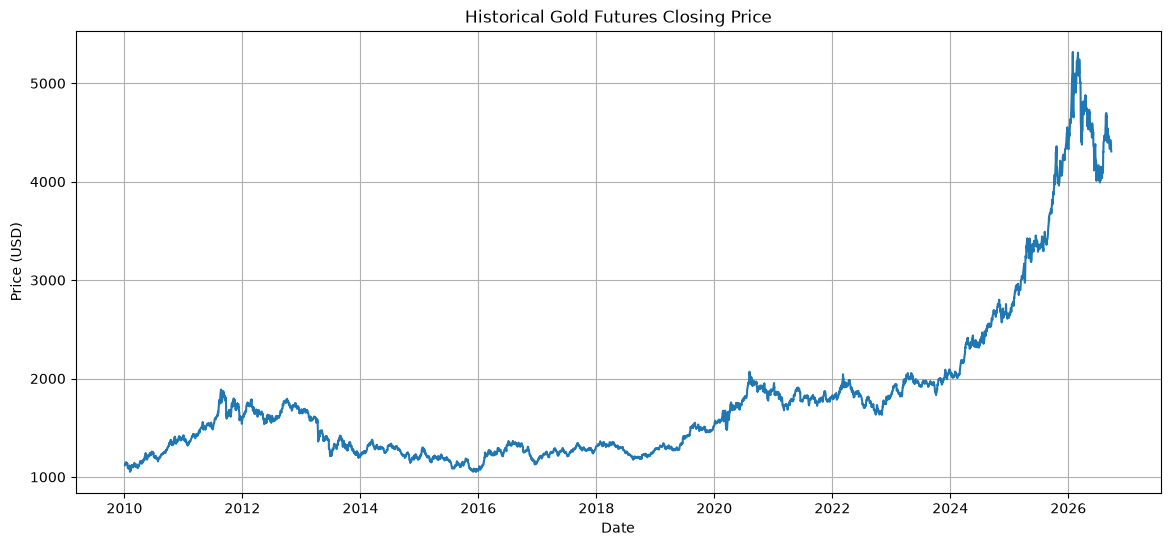

In [26]:
plt.figure(figsize=(14, 6))

plt.plot(gold.index, gold["Close"])

plt.title("Historical Gold Futures Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)

plt.show()

In [27]:
processed_file = PROCESSED_DIR / "gold_clean.csv"

gold.to_csv(processed_file)

print(f"Processed data saved successfully:\n{processed_file}")

Processed data saved successfully:
c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\processed\gold_clean.csv


## Phase 2 Summary

The raw gold futures dataset was cleaned and prepared for financial
time-series analysis.

The following steps were completed:

- Simplified the MultiIndex column structure
- Selected relevant OHLCV variables
- Prepared the Date index
- Checked missing values
- Checked duplicate dates
- Validated price values
- Verified chronological ordering
- Generated descriptive statistics
- Visualized the historical closing price
- Saved the processed dataset

The cleaned dataset is now ready for return calculation and volatility analysis.

# Phase 3 — Return Analysis

In this phase, historical gold price data is transformed into daily
returns and log returns.

Returns are the primary input for volatility and financial risk analysis.

The main objectives are:

- Calculate daily percentage returns
- Calculate logarithmic returns
- Compare the two return measures
- Analyze return distribution
- Calculate descriptive statistics
- Prepare the dataset for volatility modeling

In [29]:
processed_file = PROCESSED_DIR / "gold_clean.csv"

gold = pd.read_csv(
    processed_file,
    parse_dates=["Date"],
    index_col="Date"
)

gold.head()

,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54


## Daily Return

Daily return measures the percentage change in the closing price
from one trading day to the next.

In [30]:
gold["Daily_Return"] = gold["Close"].pct_change()

gold[["Close", "Daily_Return"]].head(10)

,Close,Daily_Return
Date,,
2010-01-04,1117.699951,NaN
2010-01-05,1118.099976,0.000358
2010-01-06,1135.900024,0.015920
2010-01-07,1133.099976,-0.002465
2010-01-08,1138.199951,0.004501
2010-01-11,1150.699951,0.010982
2010-01-12,1128.900024,-0.018945
2010-01-13,1136.400024,0.006644
2010-01-14,1142.599976,0.005456


## Log Return

Log return is calculated as the natural logarithm of the ratio
between the current closing price and the previous closing price.

Log returns are commonly used in financial time-series analysis
because they are additive over time.

In [31]:
gold["Log_Return"] = np.log(
    gold["Close"] / gold["Close"].shift(1)
)

gold[["Close", "Daily_Return", "Log_Return"]].head(10)

,Close,Daily_Return,Log_Return
Date,,,
2010-01-04,1117.699951,NaN,NaN
2010-01-05,1118.099976,0.000358,0.000358
2010-01-06,1135.900024,0.015920,0.015795
2010-01-07,1133.099976,-0.002465,-0.002468
2010-01-08,1138.199951,0.004501,0.004491
2010-01-11,1150.699951,0.010982,0.010922
2010-01-12,1128.900024,-0.018945,-0.019127
2010-01-13,1136.400024,0.006644,0.006622
2010-01-14,1142.599976,0.005456,0.005441


In [32]:
gold[["Daily_Return", "Log_Return"]].isnull().sum()

Daily_Return    1
Log_Return      1
dtype: int64

## Return Statistics

Descriptive statistics are calculated to understand the central tendency,
dispersion, and distribution characteristics of gold returns.

In [33]:
return_stats = gold[
    ["Daily_Return", "Log_Return"]
].describe()

return_stats

,Daily_Return,Log_Return
count,4206.000000,4206.000000
mean,0.000380,0.000321
std,0.010838,0.010875
min,-0.107796,-0.114060
25%,-0.004671,-0.004682
50%,0.000428,0.000428
75%,0.005978,0.005960
max,0.060697,0.058926


In [34]:
return_distribution = pd.DataFrame({
    "Mean": gold[["Daily_Return", "Log_Return"]].mean(),
    "Std": gold[["Daily_Return", "Log_Return"]].std(),
    "Skewness": gold[["Daily_Return", "Log_Return"]].skew(),
    "Kurtosis": gold[["Daily_Return", "Log_Return"]].kurt()
})

return_distribution

,Mean,Std,Skewness,Kurtosis
Daily_Return,0.000380,0.010838,-0.599546,6.697263
Log_Return,0.000321,0.010875,-0.741513,7.551093


## Daily Return Time Series

The daily return series is visualized to identify periods of unusually
large positive or negative movements.

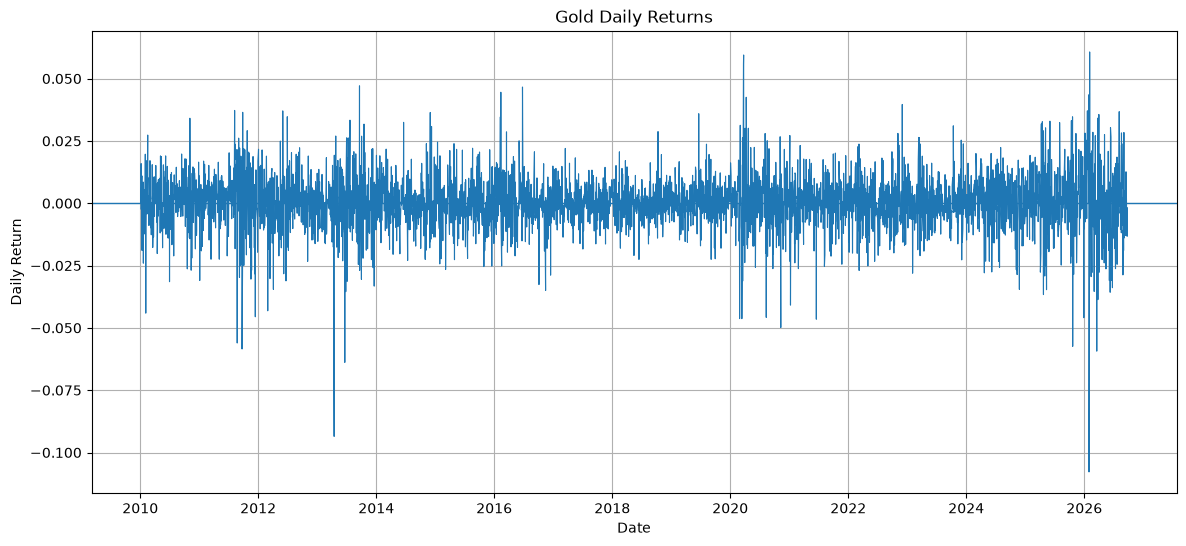

In [35]:
plt.figure(figsize=(14, 6))

plt.plot(
    gold.index,
    gold["Daily_Return"],
    linewidth=0.8
)

plt.title("Gold Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.axhline(0, linewidth=1)

plt.grid(True)
plt.show()

## Distribution of Daily Returns

The distribution of daily returns is examined to evaluate its shape,
dispersion, and potential deviation from a normal distribution.

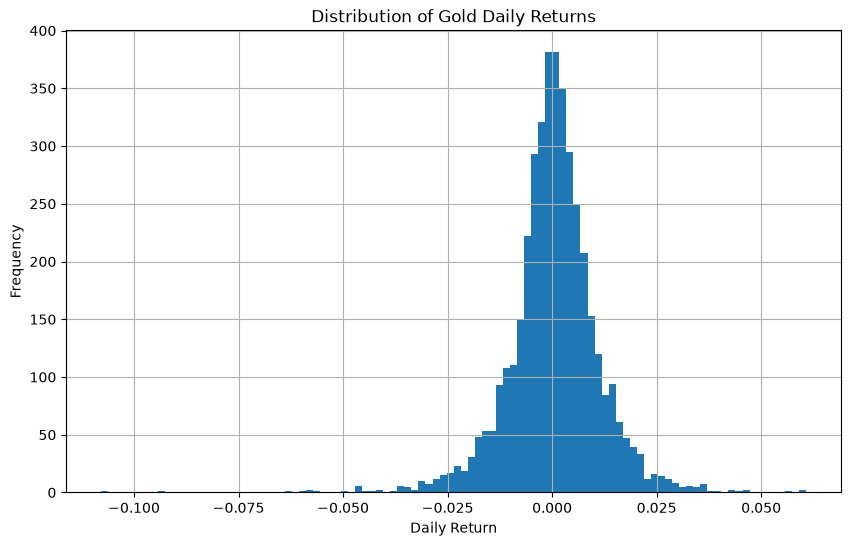

In [36]:
plt.figure(figsize=(10, 6))

plt.hist(
    gold["Daily_Return"].dropna(),
    bins=100
)

plt.title("Distribution of Gold Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.grid(True)
plt.show()

In [37]:
largest_positive = gold["Daily_Return"].nlargest(10)

largest_negative = gold["Daily_Return"].nsmallest(10)

print("Largest Positive Returns:")
display(largest_positive)

print("\nLargest Negative Returns:")
display(largest_negative)

Largest Positive Returns:


Date
2026-02-03    0.060697
2020-03-24    0.059477
2020-03-23    0.055930
2013-09-19    0.047102
2016-06-24    0.046622
2016-02-11    0.044530
2026-01-28    0.043482
2020-04-09    0.042512
2022-12-01    0.039633
2011-08-08    0.037239
Name: Daily_Return, dtype: float64


Largest Negative Returns:


Date
2026-01-30   -0.107796
2013-04-15   -0.093538
2013-06-20   -0.063847
2026-03-19   -0.059332
2011-09-23   -0.058475
2025-10-21   -0.057416
2011-08-24   -0.056073
2020-11-09   -0.049854
2021-06-17   -0.046524
2020-03-13   -0.046310
Name: Daily_Return, dtype: float64

In [38]:
returns_file = PROCESSED_DIR / "gold_returns.csv"

gold.to_csv(returns_file)

print(f"Return dataset saved successfully:\n{returns_file}")

Return dataset saved successfully:
c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\processed\gold_returns.csv


## Phase 3 Summary

Daily and logarithmic returns were calculated from historical gold
closing prices.

The return series was analyzed using:

- Descriptive statistics
- Standard deviation
- Skewness
- Kurtosis
- Time-series visualization
- Return distribution
- Extreme positive and negative returns

The resulting dataset has been saved as `gold_returns.csv`.

This dataset will be used in the next phase for historical and
rolling volatility analysis.

# Phase 4 — Volatility Analysis

In this phase, the volatility of gold returns is analyzed using
historical and rolling volatility measures.

The main objectives are:

- Calculate historical daily volatility
- Calculate rolling volatility
- Annualize volatility
- Compare short-term and medium-term volatility
- Identify periods of volatility clustering
- Prepare the return series for GARCH modeling

In [41]:
returns_file = PROCESSED_DIR / "gold_returns.csv"

gold = pd.read_csv(
    returns_file,
    parse_dates=["Date"],
    index_col="Date"
)

gold.head()

,Open,High,Low,Close,Volume,Daily_Return,Log_Return
Date,,,,,,,
2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184,NaN,NaN
2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53,0.000358,0.000358
2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363,0.015920,0.015795
2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56,-0.002465,-0.002468
2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54,0.004501,0.004491


## Historical Volatility

Historical volatility is measured using the standard deviation
of daily returns.

This provides a single measure of the overall dispersion of
gold daily returns across the sample period.

In [42]:
daily_volatility = gold["Daily_Return"].std()

print(f"Daily Historical Volatility: {daily_volatility:.6%}")

Daily Historical Volatility: 1.083789%


## Annualized Volatility

Daily volatility is annualized using 252 trading days per year.

Annualized volatility allows the volatility measure to be expressed
on a yearly basis.

In [43]:
annualized_volatility = daily_volatility * np.sqrt(252)

print(f"Annualized Volatility: {annualized_volatility:.6%}")

Annualized Volatility: 17.204615%


## Rolling Volatility

Rolling volatility measures how return dispersion changes over time.

Two rolling windows are used:

- 7 trading days — short-term volatility
- 30 trading days — medium-term volatility

In [44]:
gold["Volatility_7D"] = (
    gold["Daily_Return"]
    .rolling(window=7)
    .std()
)

gold["Volatility_30D"] = (
    gold["Daily_Return"]
    .rolling(window=30)
    .std()
)

gold[[
    "Daily_Return",
    "Volatility_7D",
    "Volatility_30D"
]].tail()

,Daily_Return,Volatility_7D,Volatility_30D
Date,,,
2026-09-18,0.005728,0.009319,0.013596
2026-09-21,-0.009266,0.008838,0.013048
2026-09-22,-0.001711,0.008830,0.013023
2026-09-23,-0.013253,0.008903,0.013197
2026-09-24,-0.002547,0.008816,0.013137


In [45]:
gold["Annualized_Volatility_7D"] = (
    gold["Volatility_7D"] * np.sqrt(252)
)

gold["Annualized_Volatility_30D"] = (
    gold["Volatility_30D"] * np.sqrt(252)
)

gold[[
    "Annualized_Volatility_7D",
    "Annualized_Volatility_30D"
]].tail()

,Annualized_Volatility_7D,Annualized_Volatility_30D
Date,,
2026-09-18,0.147939,0.215835
2026-09-21,0.140292,0.207138
2026-09-22,0.140167,0.206729
2026-09-23,0.141333,0.209492
2026-09-24,0.139942,0.208543


## Rolling Volatility Over Time

Rolling volatility is visualized to identify periods of elevated
and subdued market risk.

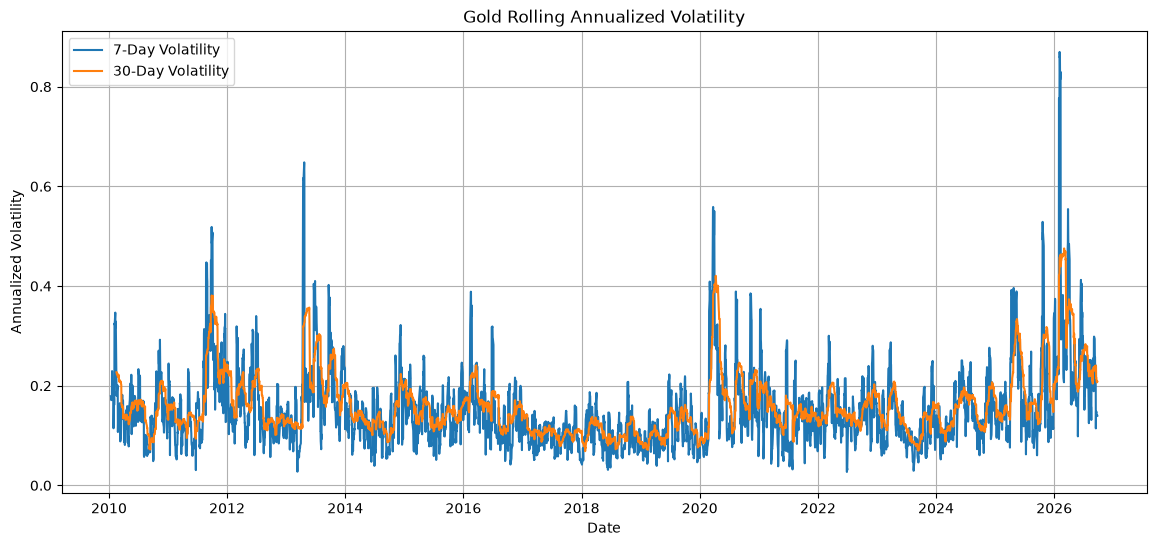

In [46]:
plt.figure(figsize=(14, 6))

plt.plot(
    gold.index,
    gold["Annualized_Volatility_7D"],
    label="7-Day Volatility"
)

plt.plot(
    gold.index,
    gold["Annualized_Volatility_30D"],
    label="30-Day Volatility"
)

plt.title("Gold Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")

plt.legend()
plt.grid(True)

plt.show()

In [47]:
volatility_stats = gold[
    [
        "Volatility_7D",
        "Volatility_30D",
        "Annualized_Volatility_7D",
        "Annualized_Volatility_30D"
    ]
].describe()

volatility_stats

,Volatility_7D,Volatility_30D,Annualized_Volatility_7D,Annualized_Volatility_30D
count,4200.000000,4177.000000,4200.000000,4177.000000
mean,0.009624,0.010101,0.152774,0.160347
std,0.005146,0.003992,0.081691,0.063364
min,0.001698,0.004324,0.026953,0.068639
25%,0.006264,0.007551,0.099436,0.119862
50%,0.008498,0.009101,0.134909,0.144479
75%,0.011558,0.011480,0.183470,0.182233
max,0.054785,0.029950,0.869691,0.475444


## Highest Volatility Periods

The periods with the highest observed rolling volatility are identified
to investigate major volatility regimes in the gold futures market.

In [48]:
top_volatility_periods = (
    gold["Annualized_Volatility_30D"]
    .nlargest(10)
)

top_volatility_periods

Date
2026-03-03    0.475444
2026-03-11    0.469699
2026-03-10    0.468079
2026-03-09    0.465364
2026-03-06    0.465258
2026-03-05    0.465242
2026-03-04    0.465042
2026-02-24    0.464740
2026-02-10    0.463448
2026-02-23    0.462799
Name: Annualized_Volatility_30D, dtype: float64

## Absolute Returns and Volatility

Absolute returns are compared with rolling volatility.

Large absolute returns are expected to be associated with periods
of elevated volatility.

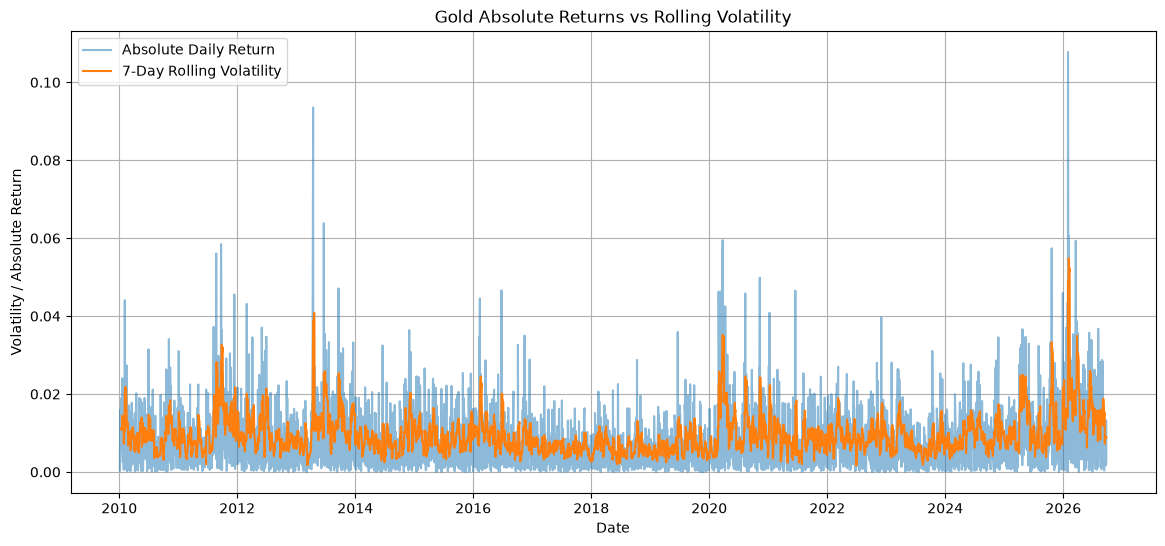

In [49]:
gold["Absolute_Return"] = gold["Daily_Return"].abs()

plt.figure(figsize=(14, 6))

plt.plot(
    gold.index,
    gold["Absolute_Return"],
    label="Absolute Daily Return",
    alpha=0.5
)

plt.plot(
    gold.index,
    gold["Volatility_7D"],
    label="7-Day Rolling Volatility"
)

plt.title("Gold Absolute Returns vs Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility / Absolute Return")

plt.legend()
plt.grid(True)

plt.show()

In [50]:
volatility_correlation = gold[
    ["Absolute_Return", "Volatility_7D"]
].corr()

volatility_correlation

,Absolute_Return,Volatility_7D
Absolute_Return,1.00000,0.46612
Volatility_7D,0.46612,1.00000


In [51]:
volatility_file = PROCESSED_DIR / "gold_volatility.csv"

gold.to_csv(volatility_file)

print(f"Volatility dataset saved successfully:\n{volatility_file}")

Volatility dataset saved successfully:
c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\processed\gold_volatility.csv


## Phase 4 Summary

Gold volatility was analyzed using historical and rolling volatility
measures.

The analysis included:

- Historical daily volatility
- Annualized volatility
- 7-day rolling volatility
- 30-day rolling volatility
- Volatility regime identification
- Absolute return analysis
- Volatility correlation analysis

The results provide an initial view of time-varying volatility and
volatility clustering in gold futures returns.

The resulting dataset has been saved as `gold_volatility.csv`.

The next phase will use GARCH modeling to formally model the
conditional volatility of gold returns.

In [52]:
print(f"Daily Historical Volatility: {daily_volatility:.6%}")
print(f"Annualized Volatility: {annualized_volatility:.6%}")

Daily Historical Volatility: 1.083789%
Annualized Volatility: 17.204615%


In [53]:
print(volatility_stats.to_string())

       Volatility_7D  Volatility_30D  Annualized_Volatility_7D  Annualized_Volatility_30D
count    4200.000000     4177.000000               4200.000000                4177.000000
mean        0.009624        0.010101                  0.152774                   0.160347
std         0.005146        0.003992                  0.081691                   0.063364
min         0.001698        0.004324                  0.026953                   0.068639
25%         0.006264        0.007551                  0.099436                   0.119862
50%         0.008498        0.009101                  0.134909                   0.144479
75%         0.011558        0.011480                  0.183470                   0.182233
max         0.054785        0.029950                  0.869691                   0.475444


In [54]:
print(top_volatility_periods.to_string())

Date
2026-03-03    0.475444
2026-03-11    0.469699
2026-03-10    0.468079
2026-03-09    0.465364
2026-03-06    0.465258
2026-03-05    0.465242
2026-03-04    0.465042
2026-02-24    0.464740
2026-02-10    0.463448
2026-02-23    0.462799


In [55]:
print(volatility_correlation.to_string())

                 Absolute_Return  Volatility_7D
Absolute_Return          1.00000        0.46612
Volatility_7D            0.46612        1.00000
